In [15]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from optim import Adam
from MLP import MLP
from loss import MSELoss

In [17]:
torch.manual_seed(42)
x_train = torch.linspace(0, 3, 200).reshape(-1, 1)
y_train = torch.exp(x_train) + 0.1 * torch.randn_like(x_train)

# MLP

In [18]:
model = MLP()
criterion = MSELoss()
optimizer = Adam(model.params, lr=0.001)

epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()

    pred = model.forward(x_train)
    loss = criterion.forward(pred, y_train)
    dout = criterion.backward()
    
    model.backward(dout)
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch {epoch:4d}, Loss: {loss.item():.6f}')

Epoch    0, Loss: 17.427160
Epoch  100, Loss: 3.893238
Epoch  200, Loss: 2.919825
Epoch  300, Loss: 1.780797
Epoch  400, Loss: 0.870438
Epoch  500, Loss: 0.411363
Epoch  600, Loss: 0.212775
Epoch  700, Loss: 0.120786
Epoch  800, Loss: 0.075258
Epoch  900, Loss: 0.050686


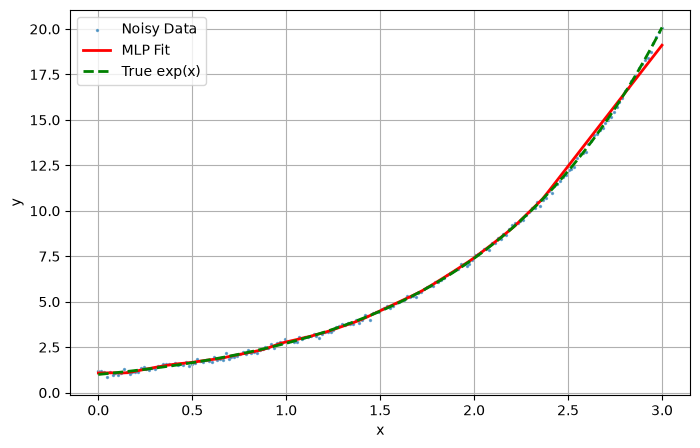

In [19]:
with torch.no_grad():
    x_test = torch.linspace(0, 3, 100).reshape(-1, 1)
    y_pred = model.forward(x_test)

plt.figure(figsize=(8,5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=2, alpha=0.6, label='Noisy Data')
plt.plot(x_test.numpy(), y_pred.numpy(), 'r-', linewidth=2, label='MLP Fit')
plt.plot(x_test.numpy(), np.exp(x_test.numpy()), 'g--', linewidth=2, label='True exp(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()